In [1]:
print("hello world")

hello world


In [2]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

In [6]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df = pd.read_excel(r"D:/Copie de BAZEA.xlsx")
df,index_a_drop = nettoyer_lignes_vides(df)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df.columns)

features_grroh = df[feature_lists["Liste_features_grroh"]]
features_radio_scan = df[feature_lists["Liste_features_scan_radio"]]
features_etiology = df[feature_lists["features_etiology"]]
features_death = df[feature_lists["death"]]
print(features_grroh)


      SEXE        age  delai_hop_rea  delai_symptome_rea  delai_diag_patho  \
0      0.0  55.000000           15.0                 3.0              17.0   
1      1.0  50.000000           13.0                 0.0               2.0   
2      1.0  58.000000            3.0                 0.0              12.0   
3      0.0  39.000000            0.0                10.0               0.0   
4      0.0  58.000000         1134.0                 6.0            1376.0   
...    ...        ...            ...                 ...               ...   
4133   1.0  54.026010           10.0                 1.0               0.0   
4134   1.0  57.598905           15.0                 0.0               0.0   
4135   1.0  68.873374            1.0                 1.0               0.0   
4136   0.0  60.993840            0.0                 2.0               0.0   
4137   1.0  76.336756            1.0                 1.0               0.0   

      Hemopathie REM  NCUR  AUTOGREFFE  ALLOGREFFE  ... prophy_

In [56]:
1500/60

25.0

In [57]:

sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,renommer_df

mapping_df, rename_dict = construire_mapping_renommage(feature_lists["Liste_features_grroh"])
df_renomme = renommer_df(features_grroh, mapping_df)

L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
features_grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)
print(df_renomme.columns)

🔹 Age → NaN remplacés par la médiane (63.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (38.1)
🔹 Neutrophils → NaN remplacés par la médiane (0.0)
🔹 Leukocytes → NaN remplacés par la médiane (8.2)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (136.0)

✅ Nettoyage terminé. NaN restants : 0
Index(['Sex', 'Age', 'delai_hop_rea', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU',
       'Hem_mal', 'REM', 'NCUR', 'AUTOGREFFE', 'ALLOGREFFE', 'DCHIM', 'LCHIM',
       'Sys_dis', 'Solid_tumor', 'Organ_transpl', 'IMMUNSUP', 'Type_IS',
       'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_viral', 'GLASGOW', 'SOFA_score', 'Hemoptysis', 'Resp_rate',
       'SpO2', 'Temp', 'SPAO2FIO2', 'Neutrophils', 'Leukocytes', 'HSCT_BMT',
       'Chemotherapy', 'Immuno_drugs', 'Dis_status HEM',
       'PaO2/FiO2 VALUE VALUE'],
      dtype='o

In [11]:
df["DIAGPRINCIPAL_final.x"].value_counts()

DIAGPRINCIPAL_final.x
2               438
0               411
BACT            261
BACT DOCU       184
UNDETERMINED    176
               ... 
ENTEROVIRUS       1
coronavirus       1
rhinovirus        1
trichosporon      1
INFLuenza         1
Name: count, Length: 75, dtype: int64

In [7]:
df.dtypes[30:50]


TYPTRANSPL                 object
DATGREFFE          datetime64[ns]
Maladie_syst                int64
type_MS                    object
CORTICO                   float64
MDOSCORT                   object
IMMUNSUP                  float64
Type_IS                    object
remarques_TTT              object
LCHIM                     float64
NCUR                      float64
REM                        object
AUTOGREFFE                float64
ALLOGREFFE                float64
DATALLO            datetime64[ns]
DATAUTO            datetime64[ns]
DCHIM                      object
PS                         object
prophy_antifung           float64
prphy_pcp                 float64
dtype: object

# Graphique de nom de maladie du sang

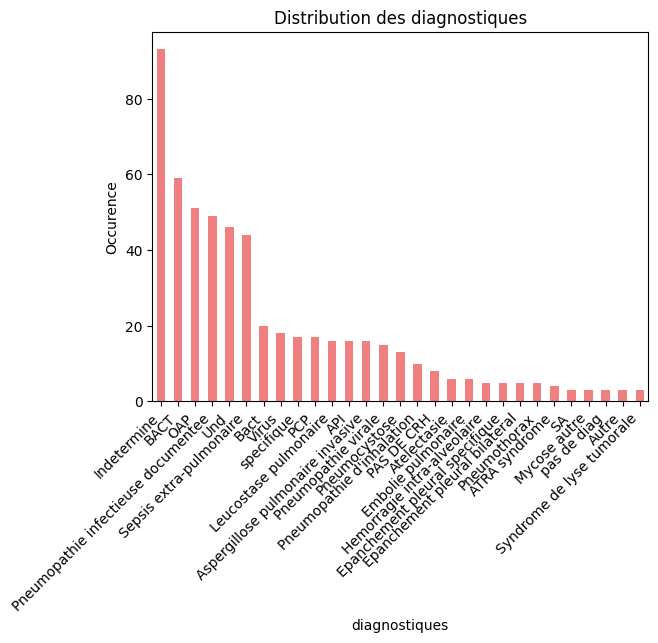

In [19]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')

plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()